## Parse data

In [30]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np
import pickle

import pickle
from common.consts import groupByResidue, groupByProperty, mutation_map, proteins
from common.utils import estimateMFPT

thresholds = np.arange(0.2, 0.50, 0.04)
short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

eigenvalue_data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
dot_data = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
avg_change_diff_data = pd.read_csv('../data/average_change_difference.csv', index_col='Mutant')


def collect_df(all_mfpt, th: float, sample_size: int):
    rows = []

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.sort(np.array(all_mfpt[long_name][th]))[:sample_size]
        mfpt, lim = estimateMFPT(s, 10)
        # print(f"{long_name} ({short}): {(mfpt * 1e-6):.4g} us, selected first {lim:.4g} samples")

        dot = dot_data['full_evec_dot'].get(short, None)
        avg_change_diff = avg_change_diff_data['AvgChange_Diff_F-U'].get(short, None)

        rows.append({
            "long": long_name,
            "short": short,
            "eigenvalue": eigenvalue_data.loc[short, "eigenvalue"],
            "mfpt": mfpt,
            "lim": lim,
            "dot": dot,
            "avg_change_diff": avg_change_diff,
            "residue_idx": short_to_residue.get(short),        # 2/7/9 or None
            "property_grp": short_to_property.get(short),      # "RHKDE"/... or None
        })

    df = pd.DataFrame(rows)
    df.set_index("short", inplace=True)
    return df

def color_map(keys):
    # stable color cycle
    base = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
    return {k: next(base) for k in keys}


## MFPT correlation

/home/jilkinalex/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/home/jilkinalex/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


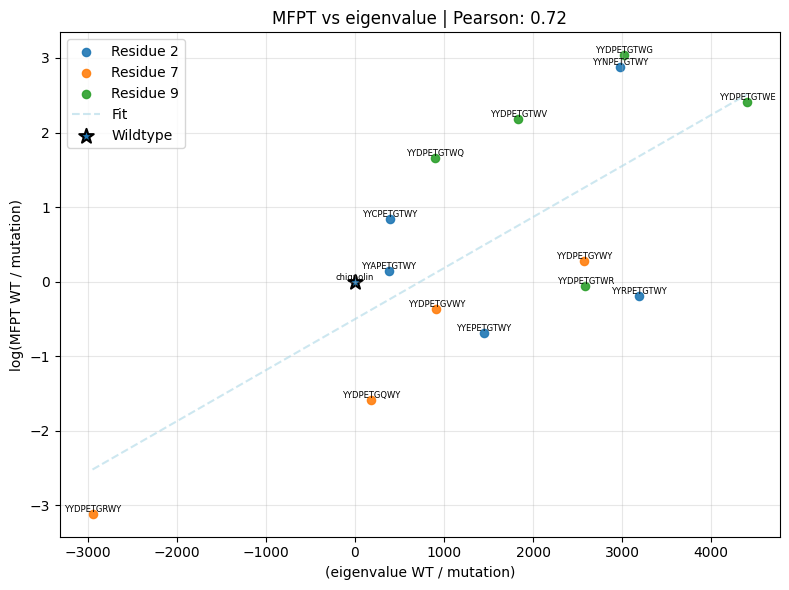

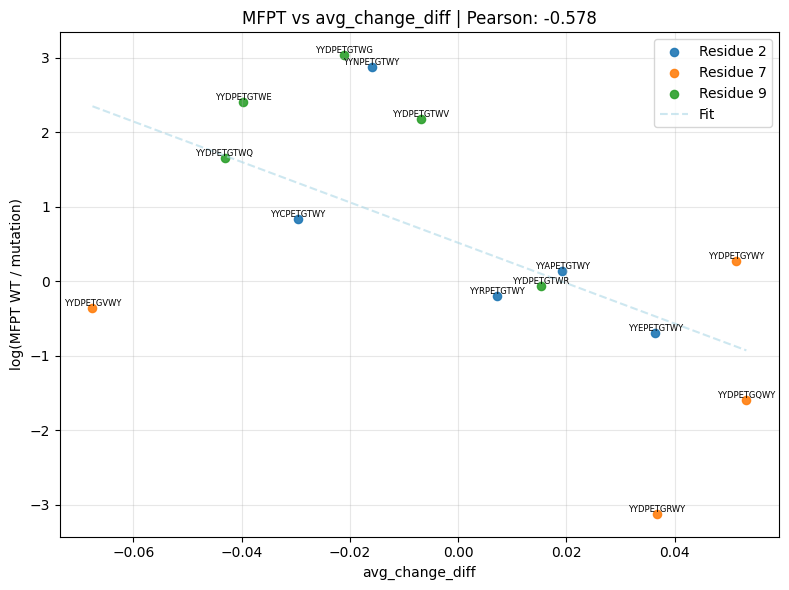

(-0.5781715154336835, -0.5516483516483517)

In [31]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_mfpt_corr(df, prop_col, wt_label='Wildtype', group_col='residue_idx',
                   annotate=False, th=None, log_prop=True, showSlope = False):
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_prop = df.loc[wt_label, prop_col]

    def ratio_or_raw(wt, arr, use_log):
        arr = np.asarray(arr, float)
        if pd.isna(wt):            # no WT value
            return arr
        if use_log:
            if wt <= 0 or np.any(arr <= 0):
                raise ValueError(f"Nonpositive values in '{prop_col}' — log undefined.")
            return wt - arr
        return wt - arr

    x_all = ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop)
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    mask = np.isfinite(x_all) & np.isfinite(y_all)

    pearson, _  = stats.pearsonr(x_all[mask], y_all[mask])
    spearman, _ = stats.spearmanr(x_all[mask], y_all[mask])

    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())
    res_colors = color_map(res_keys) if 'color_map' in globals() else {k: None for k in res_keys}

    plt.figure(figsize=(8, 6))

    if annotate:
        for xv, yv, name in zip(x_all[mask], y_all[mask], df.loc[mask, 'long'].to_numpy()):
            plt.text(xv, yv, name, fontsize=6, ha='center', va='bottom')

    for k in res_keys:
        sub = df[df[group_col] == k]
        x = ratio_or_raw(wt_prop, sub[prop_col].to_numpy(), log_prop)
        y = np.log(wt_mfpt / sub['mfpt'].to_numpy())
        plt.scatter(x, y, label=f"Residue {k}", s=35, alpha=0.9, c=res_colors.get(k))

    if showSlope:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_all[mask], y_all[mask])
        xx = np.linspace(x_all[mask].min(), x_all[mask].max(), 100)
        yy = slope * xx + intercept
        plt.plot(xx, yy, color='lightblue', alpha=0.6, linestyle='--', label="Fit")
    if not pd.isna(wt_prop):
        plt.scatter(0 if log_prop else wt_prop, 0, s=120, marker='*',
                    edgecolors='k', linewidths=1.5, label=wt_label)

    xlabel = (f'({prop_col} WT / mutation)'
              if log_prop and not pd.isna(wt_prop)
              else prop_col)
    plt.xlabel(xlabel)
    plt.ylabel('log(MFPT WT / mutation)')
    t = f" | Th={th:.3g}" if th is not None else ""
    plt.title(f"MFPT vs {prop_col} | Pearson: {pearson:.3g}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pearson, spearman




sample_size = 200
th = thresholds[5]

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

df = collect_df(all_mfpt, th, sample_size)

plot_mfpt_corr(df, 'eigenvalue', annotate=True, showSlope=True)
plot_mfpt_corr(df, 'avg_change_diff', annotate=True, showSlope=True)

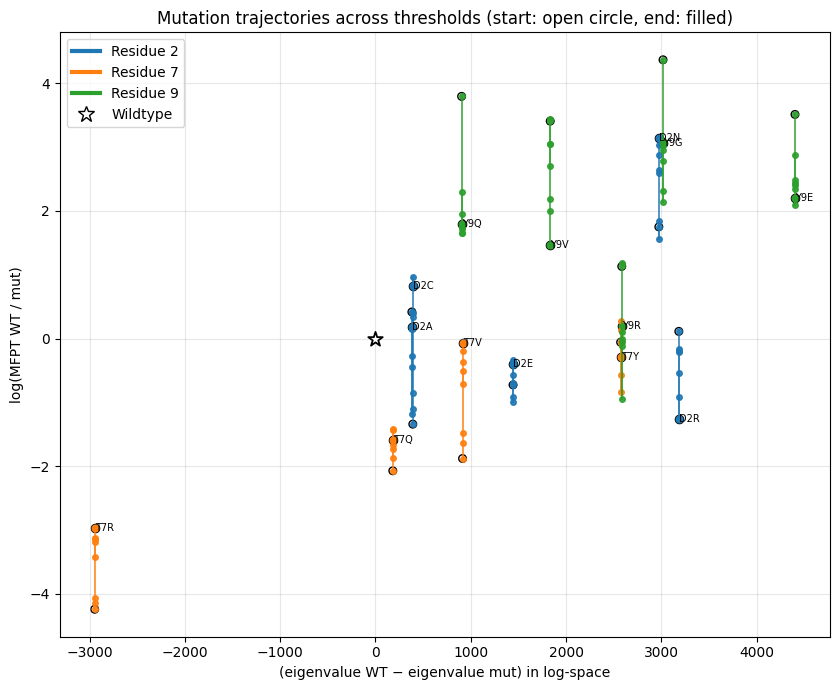

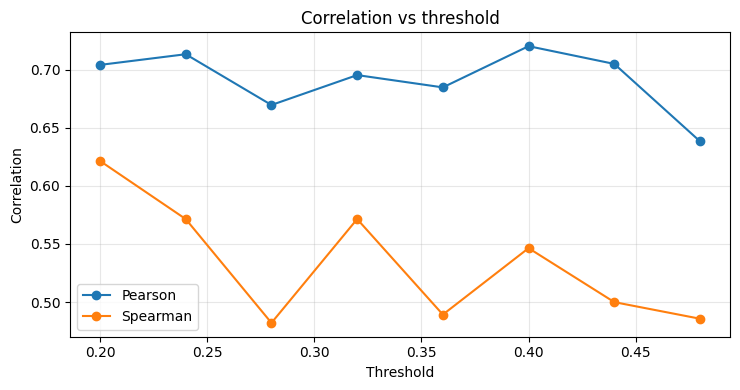

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def plot_mfpt_trails(thresholds, collect_df, all_mfpt, sample_size,
                     prop_col='eigenvalue', wt_label='Wildtype',
                     group_col='residue_idx', log_prop=True,
                     annotate_end=True):
    """
    thresholds: iterable of threshold values (same ones you use to build df)
    collect_df: your function collect_df(all_mfpt, th, sample_size) -> df
    all_mfpt: whatever you pass today into collect_df
    sample_size: as you use today
    """

    # Build a df per threshold
    dfs = {th: collect_df(all_mfpt, th, sample_size) for th in thresholds}

    # Intersect indices so we track the same mutants across thresholds
    idx_common = set.intersection(*(set(df.index) for df in dfs.values()))
    if wt_label in idx_common:
        idx_common.remove(wt_label)  # we'll place WT separately at (0,0) if needed
    idx_common = sorted(idx_common)

    # Colors per residue
    # Try user color_map(res_keys), else assign from matplotlib
    res_keys = sorted({int(v) for df in dfs.values()
                       for v in df[group_col].dropna().unique()})
    if 'color_map' in globals():
        cmap = color_map(res_keys)
    else:
        base = plt.cm.get_cmap('tab20', len(res_keys))
        cmap = {k: base(i) for i, k in enumerate(res_keys)}

    def ratio_or_raw(wt, arr, use_log):
        arr = np.asarray(arr, float)
        if wt is None or (isinstance(wt, float) and np.isnan(wt)):
            return arr
        if use_log:
            if wt <= 0 or np.any(arr <= 0):
                raise ValueError(f"Nonpositive values in '{prop_col}' — log undefined.")
            return wt - arr
        return wt - arr

    # Precompute positions per mutant across thresholds
    trails = {}  # name -> dict(th -> (x, y))
    wt_xy = {}   # th -> (x_wt, y_wt) for plotting the WT star if desired

    for th, df in dfs.items():
        wt_mfpt = float(df.loc[wt_label, 'mfpt'])
        wt_prop = df.loc[wt_label, prop_col] if wt_label in df.index else np.nan

        # Save WT position (0,0 in log-ratio space if both defined)
        if not (isinstance(wt_prop, float) and np.isnan(wt_prop)):
            wt_xy[th] = (0 if log_prop else float(wt_prop), 0.0)
        else:
            wt_xy[th] = None

        # Compute per-mutant
        for name in idx_common:
            sub = df.loc[name]
            x = ratio_or_raw(wt_prop, np.array([sub[prop_col]]), log_prop)[0]
            y = np.log(wt_mfpt / float(sub['mfpt']))
            if name not in trails: trails[name] = {}
            trails[name][th] = (x, y)

    fig, ax = plt.subplots(figsize=(8.5, 7))
    for name in idx_common:
        any_df = next(iter(dfs.values()))
        res_id = any_df.loc[name, group_col]
        col = cmap.get(int(res_id), None)

        xy = np.array([trails[name][th] for th in thresholds if th in trails[name]])
        if xy.size == 0: 
            continue

        ax.plot(xy[:,0], xy[:,1], marker='o', linewidth=1.2, markersize=4, alpha=0.9, c=col)

        ax.scatter(xy[0,0], xy[0,1], s=30, facecolors='none', edgecolors='k', linewidths=1.0)  # start = open circle
        ax.scatter(xy[-1,0], xy[-1,1], s=40, c=col, edgecolors='k', linewidths=0.6)           # end = filled

        if annotate_end:
            ax.text(xy[-1,0], xy[-1,1], name, fontsize=7, ha='left', va='center')

    # Optional: plot WT (0,0) once if defined
    if any(v is not None for v in wt_xy.values()):
        ax.scatter(0, 0, s=120, marker='*', edgecolors='k', linewidths=1.3, c='white', zorder=5, label=wt_label)

    xlabel = (f'({prop_col} WT − {prop_col} mut) in log-space'
              if log_prop else f'{prop_col} WT − {prop_col} mut')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('log(MFPT WT / mut)')
    ax.set_title('Mutation trajectories across thresholds (start: open circle, end: filled)')

    # Build a tiny legend for residues (compact) — or comment out if too many
    # Create proxy artists for a few representative residues to keep legend small
    # (Skip if there are many residues; text clutter can be high.)
    from matplotlib.lines import Line2D
    proxies = [Line2D([0],[0], color=cmap[k], lw=3, label=f'Residue {k}') for k in res_keys[:6]]
    ax.legend(handles=proxies + [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='w',
                  markeredgecolor='k', label=wt_label, markersize=12)], frameon=True)

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    pearsons, spearmans = [], []
    for th, df in dfs.items():
        wt_mfpt = float(df.loc[wt_label, 'mfpt'])
        wt_prop = df.loc[wt_label, prop_col] if wt_label in df.index else np.nan

        x_all = ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)

        p = stats.pearsonr(x_all[mask], y_all[mask])[0]
        s = stats.spearmanr(x_all[mask], y_all[mask])[0]
        pearsons.append(p); spearmans.append(s)

    fig2, ax2 = plt.subplots(figsize=(7.5, 4))
    ax2.plot(thresholds, pearsons, marker='o', label='Pearson')
    ax2.plot(thresholds, spearmans, marker='o', label='Spearman')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Correlation')
    ax2.set_title('Correlation vs threshold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()


sample_size = 200
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

ths = thresholds[:8]

plot_mfpt_trails(
    thresholds=ths,
    collect_df=collect_df,
    all_mfpt=all_mfpt,
    sample_size=sample_size,
    prop_col='eigenvalue',
    wt_label='Wildtype',
    group_col='residue_idx',
    log_prop=True,
    annotate_end=True
)

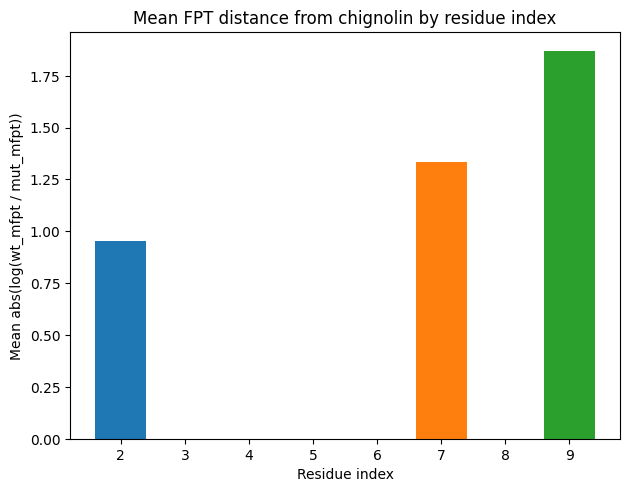

In [33]:

wt_mfpt = float(df.loc['Wildtype', 'mfpt'])
res_keys = sorted(int(k) for k in df['residue_idx'].dropna().unique())
res_colors = color_map(res_keys) if 'color_map' in globals() else {k: None for k in res_keys}

for i, group in df.groupby("residue_idx"):
    mfpt = group["mfpt"].to_numpy()

    val = np.abs(np.log((wt_mfpt / mfpt))).mean()
    
    plt.bar(i, val, color=res_colors[i])

plt.xlabel("Residue index")
plt.ylabel("Mean abs(log(wt_mfpt / mut_mfpt))")
plt.tight_layout()
plt.title("Mean FPT distance from chignolin by residue index")
plt.show()
# Highest - 9th
# Mid - 2nd
# Low - 7th

## Fit

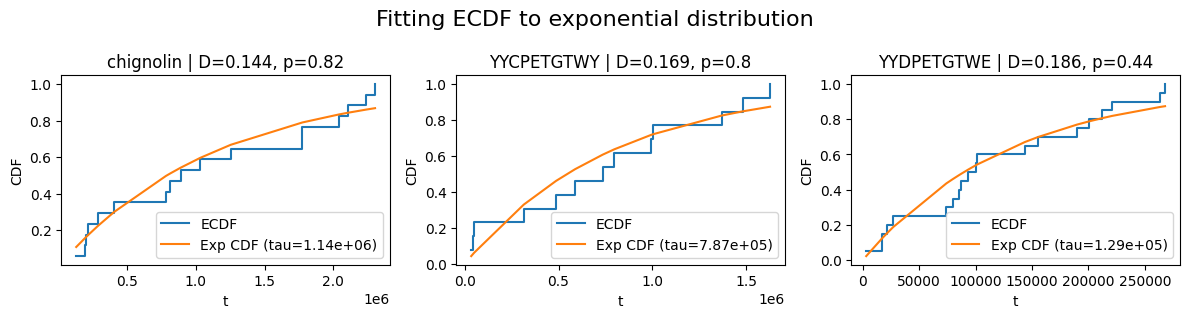

In [35]:
import math 
from scipy import optimize



def fit_exp_ks(samples):
    x = np.array(samples)
    x.sort()

    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = None ):
    ncols=3
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    
    fig.suptitle("Fitting ECDF to exponential distribution", fontsize=16)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        mfpt_base, k = estimateMFPT(np.array(all_mfpt[name][th]), 10)
        # print(mfpt_base, k)

        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{name} | " + axes[r, c].get_title())
        
    fig.tight_layout()
    return fig

th = thresholds[5]

plot_ecdfs_grid_fastest_k(all_mfpt, proteins[:3], th)
plt.show()


